In [2]:
documents = [
    "Machine learning is a branch of artificial intelligence.",
    "Deep learning uses neural networks for machine learning applications.",
    "Artificial intelligence is used in medical diagnosis and healthcare.",
    "Machine learning and artificial intelligence are widely used in healthcare.",
    "Natural language processing is an important area of artificial intelligence."
]

document_names = [
    "Document 1",
    "Document 2",
    "Document 3",
    "Document 4",
    "Document 5"
]

query = "machine learning artificial intelligence"

print("Query:", query)
print("\nDocuments:")

for name, doc in zip(document_names, documents):
    print(f"{name}: {doc}")

Query: machine learning artificial intelligence

Documents:
Document 1: Machine learning is a branch of artificial intelligence.
Document 2: Deep learning uses neural networks for machine learning applications.
Document 3: Artificial intelligence is used in medical diagnosis and healthcare.
Document 4: Machine learning and artificial intelligence are widely used in healthcare.
Document 5: Natural language processing is an important area of artificial intelligence.


In [3]:
tokenized_documents = [
    doc.lower().split()
    for doc in documents
]

tokenized_query = query.lower().split()

print("Tokenized Query:")
print(tokenized_query)

Tokenized Query:
['machine', 'learning', 'artificial', 'intelligence']


In [4]:
from rank_bm25 import BM25Okapi

bm25 = BM25Okapi(tokenized_documents)

bm25_scores = bm25.get_scores(tokenized_query)

print("BM25 Scores:")

for name, score in zip(document_names, bm25_scores):
    print(f"{name}: {score:.4f}")

BM25 Scores:
Document 1: 0.5501
Document 2: 0.4226
Document 3: 0.5141
Document 4: 0.8221
Document 5: 0.1661


In [5]:
bm25_ranking = sorted(
    zip(document_names, bm25_scores),
    key=lambda x: x[1],
    reverse=True
)

print("\nBM25 Ranking:")

for rank, (name, score) in enumerate(bm25_ranking, start=1):
    print(f"{rank}. {name} - Score: {score:.4f}")


BM25 Ranking:
1. Document 4 - Score: 0.8221
2. Document 1 - Score: 0.5501
3. Document 3 - Score: 0.5141
4. Document 2 - Score: 0.4226
5. Document 5 - Score: 0.1661


In [6]:
import math
from collections import Counter

In [7]:
# Count words in each document
document_word_counts = [
    Counter(doc.lower().split())
    for doc in documents
]

# Count all words in the collection
collection_counts = Counter()

for counter in document_word_counts:
    collection_counts.update(counter)

# Total number of words in collection
total_collection_words = sum(collection_counts.values())

print("Collection vocabulary size:", len(collection_counts))
print("Total words:", total_collection_words)

Collection vocabulary size: 29
Total words: 46


In [8]:
def jelinek_mercer_score(document_counter, query_terms,
                          collection_counts, total_collection_words,
                          document_length, lambda_value=0.7):

    score = 0.0

    for term in query_terms:

        # P(term | Document)
        term_frequency = document_counter.get(term, 0)

        if document_length > 0:
            p_term_document = term_frequency / document_length
        else:
            p_term_document = 0

        # P(term | Collection)
        collection_frequency = collection_counts.get(term, 0)

        if total_collection_words > 0:
            p_term_collection = collection_frequency / total_collection_words
        else:
            p_term_collection = 0

        # Jelinek-Mercer smoothing
        smoothed_probability = (
            lambda_value * p_term_document
            + (1 - lambda_value) * p_term_collection
        )

        # Avoid log(0)
        if smoothed_probability > 0:
            score += math.log(smoothed_probability)

    return score

In [9]:
lambda_value = 0.7

jm_scores = []

for counter in document_word_counts:

    document_length = sum(counter.values())

    score = jelinek_mercer_score(
        counter,
        tokenized_query,
        collection_counts,
        total_collection_words,
        document_length,
        lambda_value
    )

    jm_scores.append(score)

print("Jelinek-Mercer Scores:")

for name, score in zip(document_names, jm_scores):
    print(f"{name}: {score:.6f}")

Jelinek-Mercer Scores:
Document 1: -10.924157
Document 2: -12.021016
Document 3: -12.243850
Document 4: -9.586183
Document 5: -14.262290


In [10]:
jm_ranking = sorted(
    zip(document_names, jm_scores),
    key=lambda x: x[1],
    reverse=True
)

print("\nJelinek-Mercer Ranking:")

for rank, (name, score) in enumerate(jm_ranking, start=1):
    print(f"{rank}. {name} - Score: {score:.6f}")


Jelinek-Mercer Ranking:
1. Document 4 - Score: -9.586183
2. Document 1 - Score: -10.924157
3. Document 2 - Score: -12.021016
4. Document 3 - Score: -12.243850
5. Document 5 - Score: -14.262290


In [11]:
print("=" * 60)
print("COMPARISON OF DOCUMENT RANKINGS")
print("=" * 60)

print("\nBM25 Ranking:")

for rank, (name, score) in enumerate(bm25_ranking, start=1):
    print(f"{rank}. {name} - {score:.4f}")

print("\nJelinek-Mercer Ranking:")

for rank, (name, score) in enumerate(jm_ranking, start=1):
    print(f"{rank}. {name} - {score:.6f}")

COMPARISON OF DOCUMENT RANKINGS

BM25 Ranking:
1. Document 4 - 0.8221
2. Document 1 - 0.5501
3. Document 3 - 0.5141
4. Document 2 - 0.4226
5. Document 5 - 0.1661

Jelinek-Mercer Ranking:
1. Document 4 - -9.586183
2. Document 1 - -10.924157
3. Document 2 - -12.021016
4. Document 3 - -12.243850
5. Document 5 - -14.262290


In [12]:
import pandas as pd

results = pd.DataFrame({
    "Document": document_names,
    "BM25 Score": bm25_scores,
    "JM Score": jm_scores
})

results["BM25 Rank"] = (
    results["BM25 Score"]
    .rank(method="min", ascending=False)
    .astype(int)
)

results["JM Rank"] = (
    results["JM Score"]
    .rank(method="min", ascending=False)
    .astype(int)
)

results = results.sort_values("BM25 Rank")

print(results)

     Document  BM25 Score   JM Score  BM25 Rank  JM Rank
3  Document 4    0.822120  -9.586183          1        1
0  Document 1    0.550107 -10.924157          2        2
2  Document 3    0.514108 -12.243850          3        4
1  Document 2    0.422626 -12.021016          4        3
4  Document 5    0.166106 -14.262290          5        5


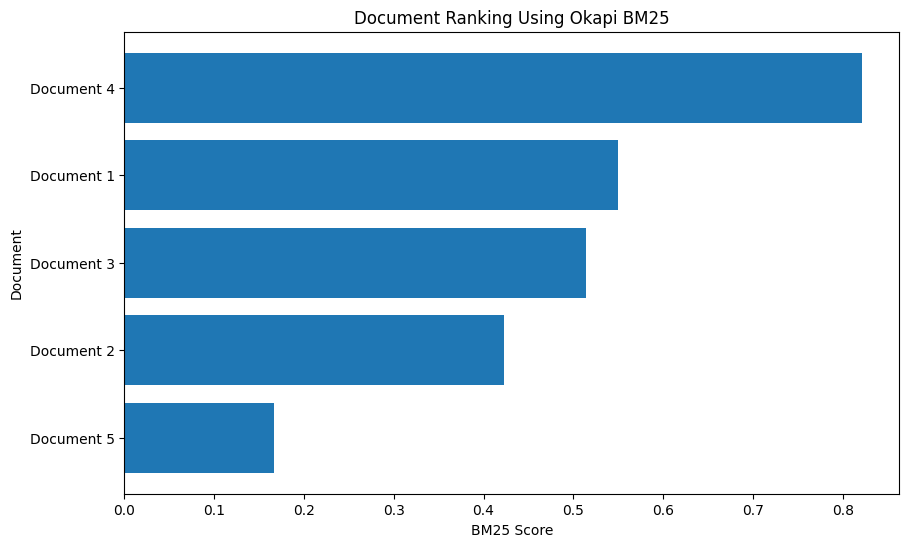

In [13]:
import matplotlib.pyplot as plt

results_sorted = results.sort_values("BM25 Score", ascending=True)

plt.figure(figsize=(10, 6))

plt.barh(
    results_sorted["Document"],
    results_sorted["BM25 Score"]
)

plt.xlabel("BM25 Score")
plt.ylabel("Document")
plt.title("Document Ranking Using Okapi BM25")

plt.show()

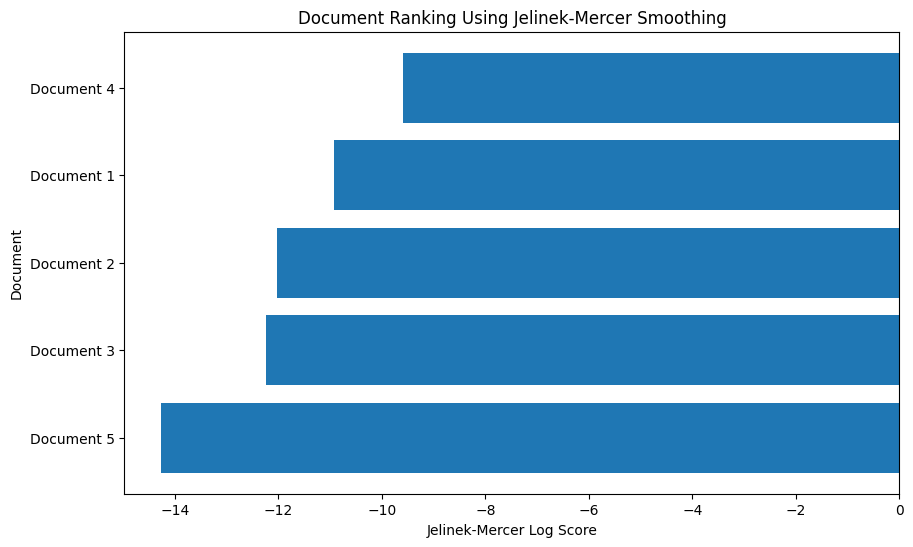

In [14]:
results_sorted = results.sort_values("JM Score", ascending=True)

plt.figure(figsize=(10, 6))

plt.barh(
    results_sorted["Document"],
    results_sorted["JM Score"]
)

plt.xlabel("Jelinek-Mercer Log Score")
plt.ylabel("Document")
plt.title("Document Ranking Using Jelinek-Mercer Smoothing")

plt.show()